In [5]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.formula.api import ols
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import f_oneway, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import plotly.express as px

In [6]:
inspection = pd.read_excel('Inspection_Data.xlsx')
inspection['INSPECTION DATE'] = pd.to_datetime(inspection['INSPECTION DATE'], origin='1899-12-30', unit='D')

In [3]:
############ DATA CLEANING ############
# Drop missing value for important variables
inspection.dropna(axis=0, how='any', subset= ['BORO','SCORE','CUISINE DESCRIPTION'], inplace=True)
inspection['missing_violation_flag'] = inspection[['VIOLATION CODE', 'VIOLATION DESCRIPTION']].isnull().any(axis=1)

# Handle restaurants with multiple inspections
average_scores = inspection.groupby('CAMIS')['SCORE'].mean().reset_index()
average_scores.columns = ['CAMIS', 'AVG_SCORE']
inspection = inspection.merge(average_scores, on='CAMIS', how='left')


# Retain only the latest inspection for regression analysis
inspection['INSPECTION DATE'] = pd.to_datetime(inspection['INSPECTION DATE'])
latest_inspections = inspection.sort_values(by=['CAMIS', 'INSPECTION DATE'], ascending=[True, False])
latest_inspections = latest_inspections.drop_duplicates(subset='CAMIS', keep='first')


# Group similar cuisine types 
cuisine_mapping = {
    'Chinese': 'Asian',
    'Asian Fusion': 'Asian',
    'Japanese': 'Asian',
    'Korean': 'Asian',
    'Italian': 'Italian/Mediterranean',
    'Pizza': 'Italian/Mediterranean',
    'Mediterranean': 'Italian/Mediterranean',
    'Mexican': 'Latin American',
    'Tex-Mex': 'Latin American',
    'Latin American': 'Latin American',
    'American': 'American',
    'Hamburgers': 'American',
    'Soul Food': 'American',
    'Indian': 'Indian',
    'Bangladeshi': 'Indian',
    'Thai': 'Southeast Asian',
    'Vietnamese': 'Southeast Asian',
    'Southeast Asian': 'Southeast Asian',
    'French': 'European',
    'European': 'European',
    'Bistro': 'European',
    'Caribbean': 'Caribbean',
    'Jamaican': 'Caribbean',
    'Middle Eastern': 'Middle Eastern',
    'Turkish': 'Middle Eastern',
    'African': 'African',
    'Ethiopian': 'African',
    'Bakery': 'Bakery/Dessert',
    'Dessert': 'Bakery/Dessert',
    'Donuts': 'Bakery/Dessert',
    'Seafood': 'Seafood',
    'Cajun': 'Seafood',
    'Other': 'Other/Unclassified'
}
inspection['CUISINE DESCRIPTION'] = inspection['CUISINE DESCRIPTION'].replace(cuisine_mapping)

# Grouping violation codes into broader categories
violation_mapping = {
    '02A': 'Food Temperature Violations',
    '02B': 'Food Temperature Violations',
    '02C': 'Food Temperature Violations',
    '04A': 'Food Handling Violations',
    '04B': 'Food Handling Violations',
    '04C': 'Food Handling Violations',
    '06A': 'Pest Control',
    '06B': 'Pest Control',
    '08A': 'Facility Maintenance',
    '08B': 'Facility Maintenance',
    '08C': 'Facility Maintenance',
    '10A': 'Hygiene and Cleanliness',
    '10B': 'Hygiene and Cleanliness',
    '99A': 'Administrative Issues',
    '99C': 'Administrative Issues',
    'Other': 'Miscellaneous'
}
inspection['VIOLATION CATEGORY'] = inspection['VIOLATION CODE'].map(violation_mapping).fillna('Miscellaneous')


/Users/charlotte/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/charlotte/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/charlotte/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/charlotte/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/Users/charlotte/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarn

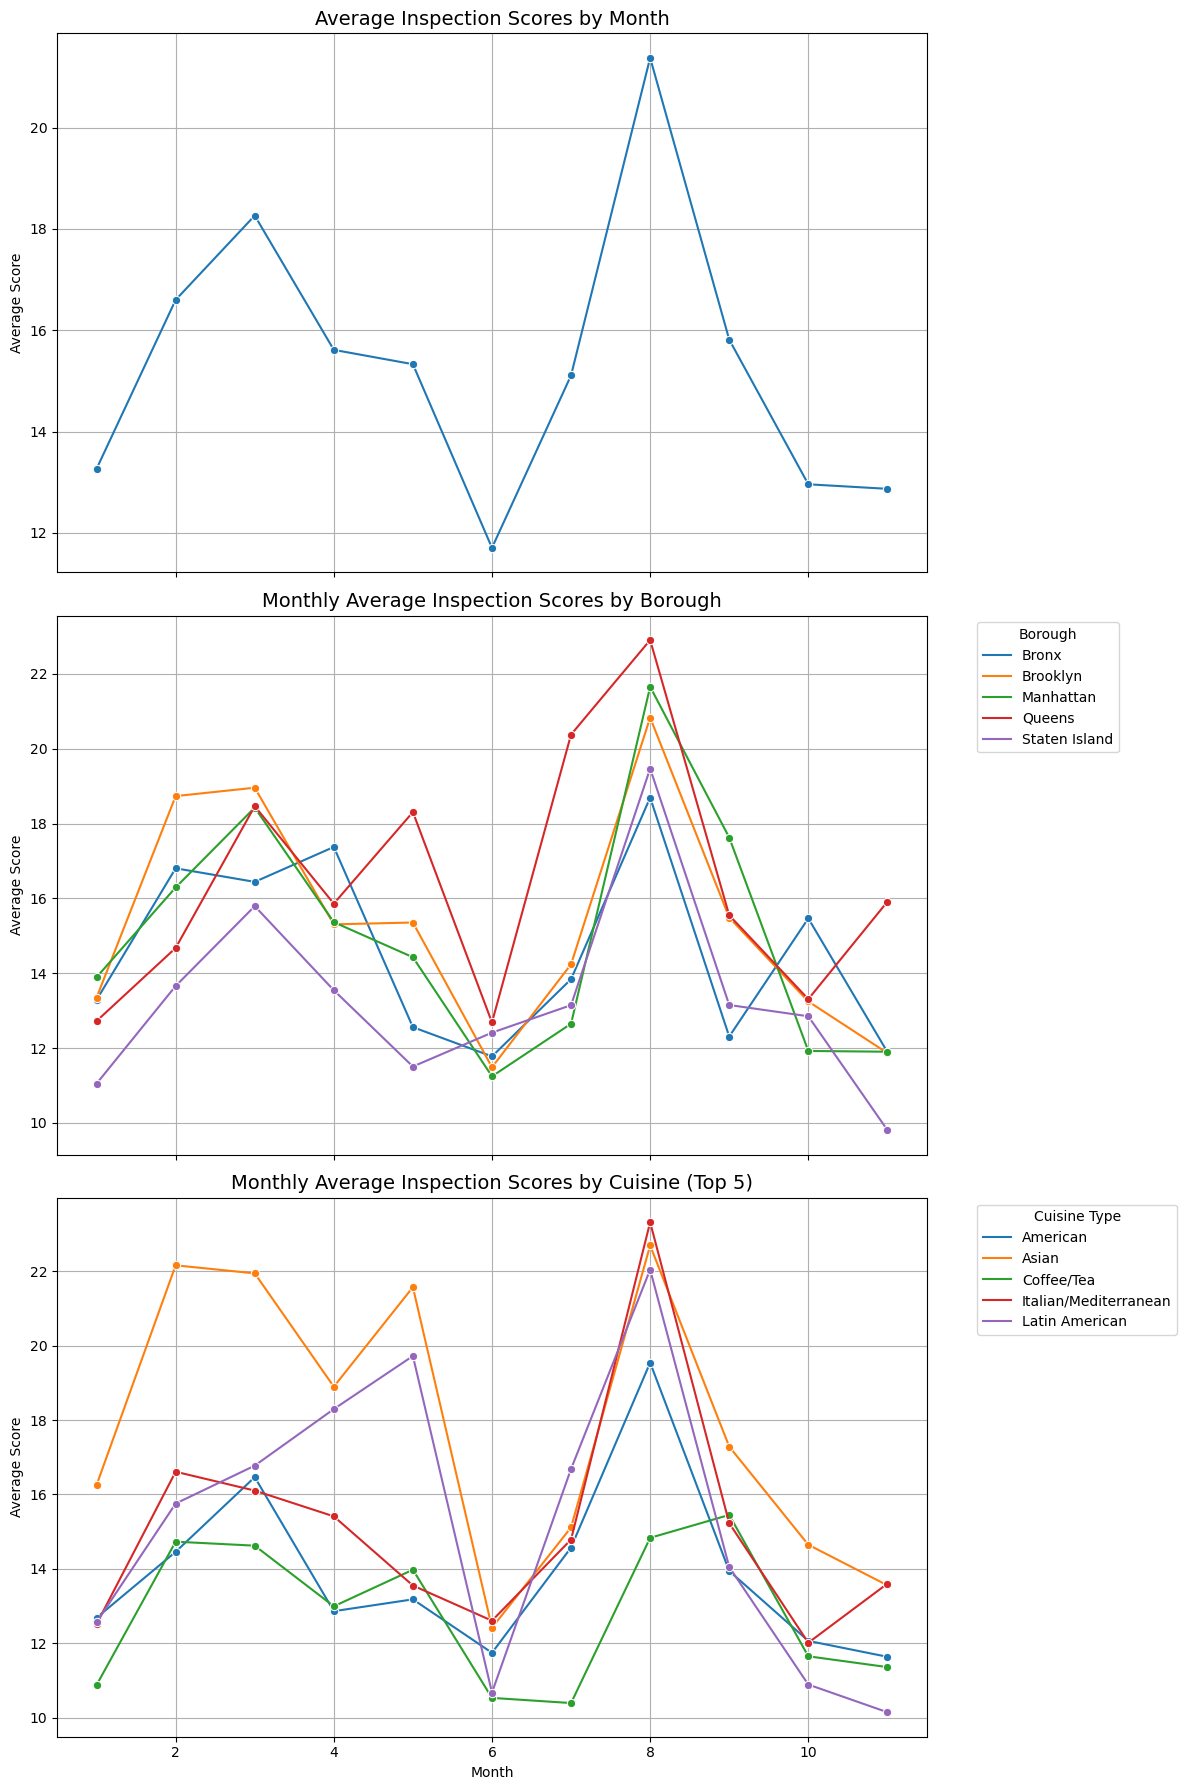

In [12]:
############ Monthly Trend ###############

# Monthly Trend Analysis: Larger Figure with 3 Subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

# Ensure 'MONTH' column exists
inspection['MONTH'] = inspection['INSPECTION DATE'].dt.month

# 1. Overall Monthly Trend
monthly_avg_scores = inspection.groupby('MONTH')['AVG_SCORE'].mean().reset_index()
sns.lineplot(data=monthly_avg_scores, x='MONTH', y='AVG_SCORE', marker='o', ax=axes[0])
axes[0].set_title('Average Inspection Scores by Month', fontsize=14)
axes[0].set_xlabel('')  # Remove x-axis label for the top plot
axes[0].set_ylabel('Average Score')
axes[0].grid()

# 2. Borough Monthly Trend
borough_monthly_avg = inspection.groupby(['BORO', 'MONTH'])['AVG_SCORE'].mean().reset_index()
sns.lineplot(data=borough_monthly_avg, x='MONTH', y='AVG_SCORE', hue='BORO', marker='o', ax=axes[1])
axes[1].set_title('Monthly Average Inspection Scores by Borough', fontsize=14)
axes[1].set_xlabel('')  # Remove x-axis label for the middle plot
axes[1].set_ylabel('Average Score')
axes[1].legend(title='Borough', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid()

# 3. Monthly Trend for Top 5 Cuisines
# Identify the top 5 cuisines by inspection frequency
top_cuisines = inspection['CUISINE DESCRIPTION'].value_counts().head(5).index
inspection_top_cuisines = inspection[inspection['CUISINE DESCRIPTION'].isin(top_cuisines)]

# Calculate average scores for top 5 cuisines
cuisine_monthly_avg = inspection_top_cuisines.groupby(['CUISINE DESCRIPTION', 'MONTH'])['AVG_SCORE'].mean().reset_index()
sns.lineplot(data=cuisine_monthly_avg, x='MONTH', y='AVG_SCORE', hue='CUISINE DESCRIPTION', marker='o', ax=axes[2])
axes[2].set_title('Monthly Average Inspection Scores by Cuisine (Top 5)', fontsize=14)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Score')
axes[2].legend(title='Cuisine Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid()

# Adjust layout for better appearance
plt.tight_layout()
plt.show()

